### Full code

In [3]:
import sys
print(sys.executable)


/Users/phinhasasmelash/Projects/witcher_character_analysis/witcher_venv/bin/python3


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import time
from selenium import webdriver
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options

/Users/phinhasasmelash/Projects/witcher_character_analysis/witcher_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [5]:
# Setup chrome options
chrome_options = Options()
chrome_options.add_argument("--headless") # Ensure GUI is off
chrome_options.add_argument("--no_sandbox")

# Create Service
webdriver_service = Service(ChromeDriverManager().install())

# Create Driver
driver = webdriver.Chrome(service = webdriver_service, options = chrome_options)

# go to the witcher wiki website (characters in books page)
page_url = "https://witcher.fandom.com/wiki/Category:Characters_in_the_stories"
driver.get(page_url)

# Find books 
book_categories = driver.find_elements(By.CLASS_NAME, 'category-page__member-link')

books = []
for category in book_categories:
    book_url = category.get_attribute('href')
    book_name = category.text
    books.append({'book_name': book_name, "url": book_url})

In [6]:
books
len(books)

12

In [7]:
# takes a while to run
character_list = []

for book in books:
    # go to book page
    driver.get(book['url'])

    character_elems = driver.find_elements(By.CLASS_NAME, 'category-page__member-link')

    for elem in character_elems:
        character_list.append({'book': book['book_name'], 'character': elem.text})

In [8]:
# convert list to a pandas list
pd.DataFrame(character_list)

,book,character
0,Category:Baptism of Fire characters,Adalia
1,Category:Baptism of Fire characters,Adela
2,Category:Baptism of Fire characters,Aen Saevherne
3,Category:Baptism of Fire characters,Aevenien
4,Category:Baptism of Fire characters,Aglaïs
...,...,...
1271,Category:Time of Contempt characters,Yanna of Murivel
1272,Category:Time of Contempt characters,Yarpen Zigrin
1273,Category:Time of Contempt characters,Yennefer of Vengerberg
1274,Category:Time of Contempt characters,Yiolenta Suarez


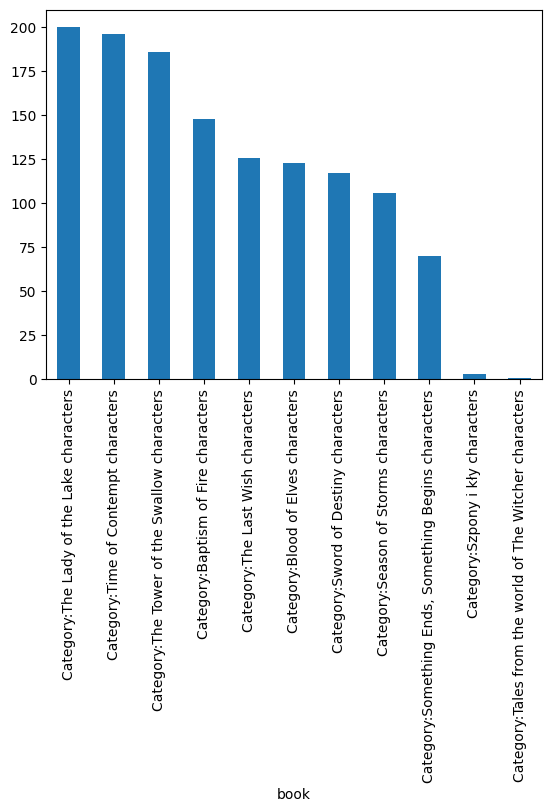

,book,character
0,Category:Baptism of Fire characters,Adalia
1,Category:Baptism of Fire characters,Adela
2,Category:Baptism of Fire characters,Aen Saevherne
3,Category:Baptism of Fire characters,Aevenien
4,Category:Baptism of Fire characters,Aglaïs
...,...,...
1271,Category:Time of Contempt characters,Yanna of Murivel
1272,Category:Time of Contempt characters,Yarpen Zigrin
1273,Category:Time of Contempt characters,Yennefer of Vengerberg
1274,Category:Time of Contempt characters,Yiolenta Suarez


In [10]:
character_df = pd.DataFrame(character_list)

character_df['book'].value_counts().plot(kind="bar")
plt.show()
character_df

## Output to .csv file

In [12]:
character_df.to_csv('characters.csv', index=False)